In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import argparse
import copy
import gc
import json
import os
import pickle
from datetime import datetime
from functools import partial
import random

import numpy as np
import psutil
import torch
from torch import nn
from tqdm import tqdm

import matplotlib.pyplot as plt

from bioplnn.models import SpatiallyEmbeddedClassifier
from bioplnn.utils import (
    initialize_dataloader,
    initialize_scheduler,
    manual_seed,
)
from bioplnn.models import SpatiallyEmbeddedRNN, SpatiallyEmbeddedAreaConfig


cabc_data_path = "/om2/user/jackking/torch-bioplnn-dev/data/easy"
checkpoint_path = "/om2/user/jackking/torch-bioplnn-dev/train/checkpoints"
dataset = "cabc"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

BATCH_SIZE = 32

In [3]:
def load_data(dataset, **args):
    train_loader, test_loader = initialize_dataloader(
        seed=42, dataset=dataset, **args
    )
    return train_loader, test_loader

In [16]:
train_loader, test_loader = load_data(dataset, batch_size=BATCH_SIZE, root=cabc_data_path, resolution=(128, 128))

In [17]:
trainset = train_loader.dataset

In [18]:
trainset[0][0].shape

torch.Size([1, 128, 128])

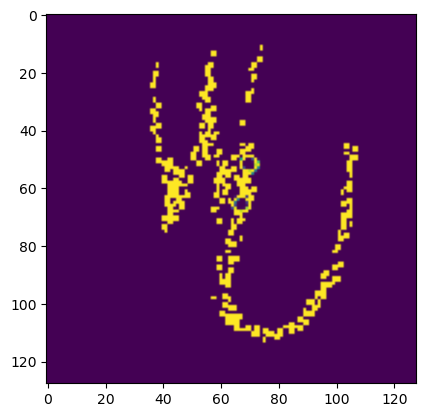

1


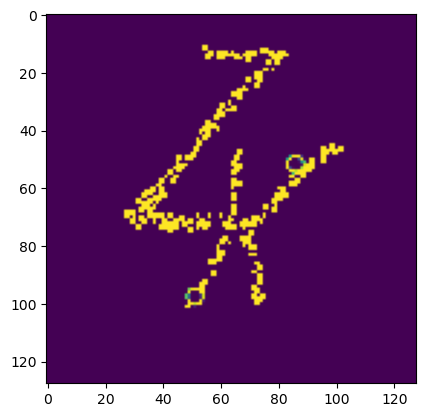

1


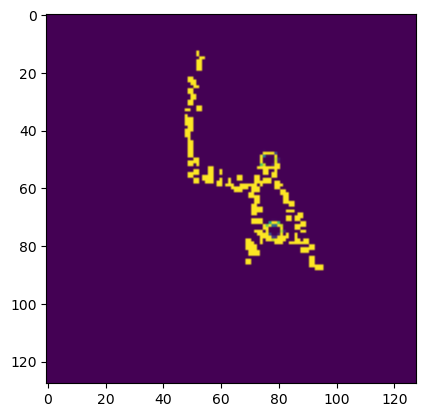

1


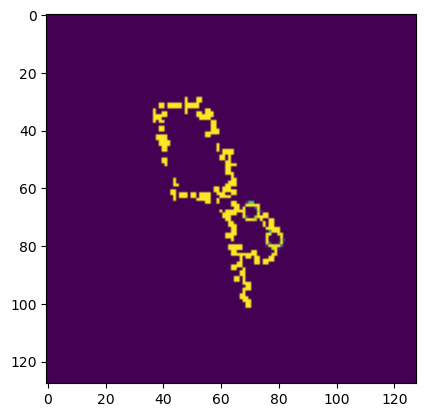

1


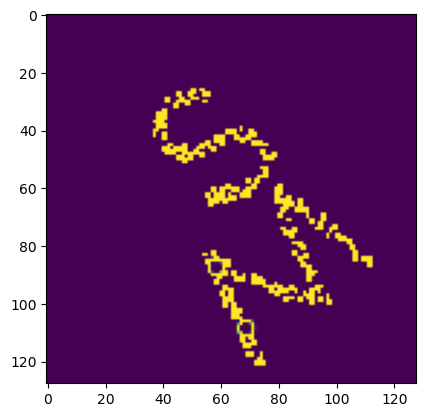

1


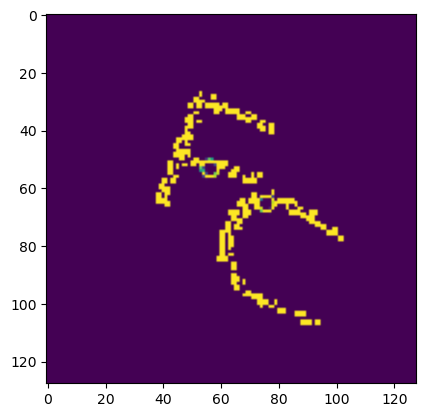

0


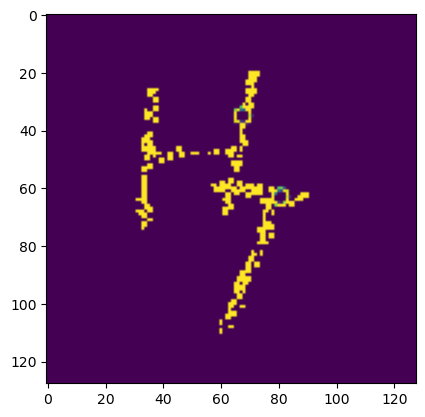

0


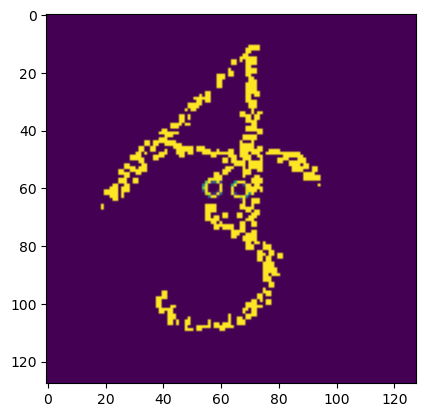

0


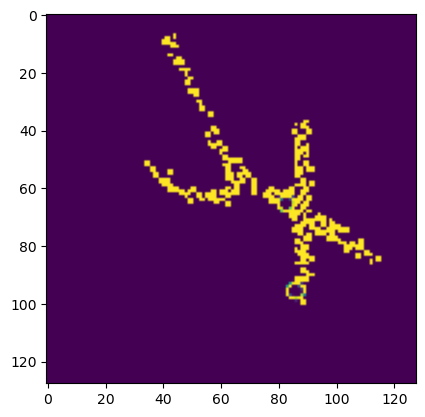

1


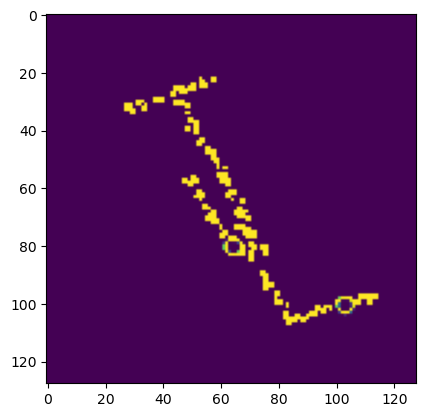

1


In [19]:
for idx in range(10):
    plt.imshow(trainset[idx][0][0])
    plt.show()
    print(trainset[idx][1])

In [2]:
area_configs_feedback_model = [
    SpatiallyEmbeddedAreaConfig(
                num_neuron_types = 2,
                num_neuron_subtypes = np.array([16, 16]),
                neuron_type_class = np.array(['excitatory', 'inhibitory']),
                inter_neuron_type_connectivity = np.array([[1, 1, 0], [1, 0, 0], [1, 1, 1], [1, 1, 0]]),
                feedback_channels = 16,
                in_size = [28, 28],
                in_channels =  1,
                out_channels = 32,
    ),
    SpatiallyEmbeddedAreaConfig(
                num_neuron_types = 2,
                num_neuron_subtypes = np.array([32, 32]),
                neuron_type_class = np.array(['excitatory', 'inhibitory']),
                inter_neuron_type_connectivity = np.array([[1, 1, 0], [1, 1, 1], [1, 1, 0]]),
                in_size = [14, 14],
                in_channels =  32,
                out_channels = 32,
    )
]

model_wFeedback = SpatiallyEmbeddedRNN(
                            num_areas = 2,
                            area_configs = area_configs_feedback_model,
                            batch_first = False,
                            inter_area_feedback_connectivity = np.array([[0, 0],[1, 0]])
                    )

In [3]:
model_wFeedback

SpatiallyEmbeddedRNN(
  (areas): ModuleList(
    (0): SpatiallyEmbeddedArea(
      (out_nonlinearity): Identity()
      (neuron_type_nonlinearity): ModuleList(
        (0-1): 2 x Sigmoid()
      )
      (convs): ModuleDict(
        (0->0): Sequential(
          (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (0->1): Sequential(
          (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (1->0): Sequential(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (2->0): Sequential(
          (0): Conv2dRectify(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (2->1): Sequential(
          (0): Conv2dRectify(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Identity()
        )
        (3->0): Sequential(
          (